[autoreload of ramlab.molecules.diatomic failed: Traceback (most recent call last):
  File "/Users/mruijzendaal/Projects/UM/ramlab/.venv/lib/python3.12/site-packages/IPython/extensions/autoreload.py", line 276, in check
    superreload(m, reload, self.old_objects)
  File "/Users/mruijzendaal/Projects/UM/ramlab/.venv/lib/python3.12/site-packages/IPython/extensions/autoreload.py", line 500, in superreload
    update_generic(old_obj, new_obj)
  File "/Users/mruijzendaal/Projects/UM/ramlab/.venv/lib/python3.12/site-packages/IPython/extensions/autoreload.py", line 397, in update_generic
    update(a, b)
  File "/Users/mruijzendaal/Projects/UM/ramlab/.venv/lib/python3.12/site-packages/IPython/extensions/autoreload.py", line 330, in update_class
    old_obj = getattr(old, key)
              ^^^^^^^^^^^^^^^^^
  File "/Users/mruijzendaal/Projects/UM/ramlab/src/ramlab/molecules/diatomic.py", line 359, in B_e
    raise NotImplementedError
NotImplementedError
]


Generating linelist file...
Calculating cross-section
1.43529218595966e-13


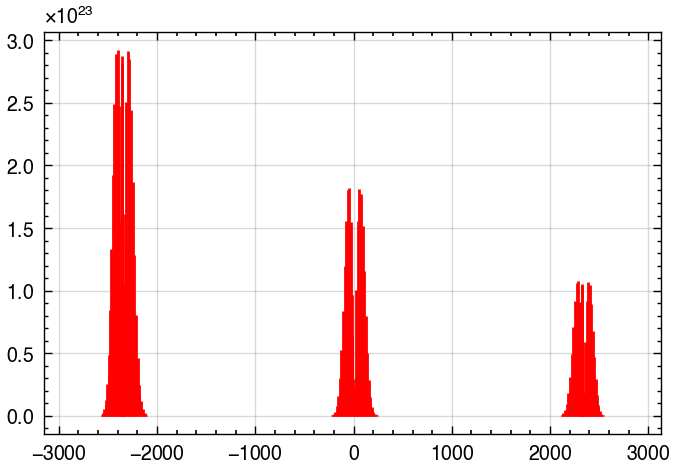

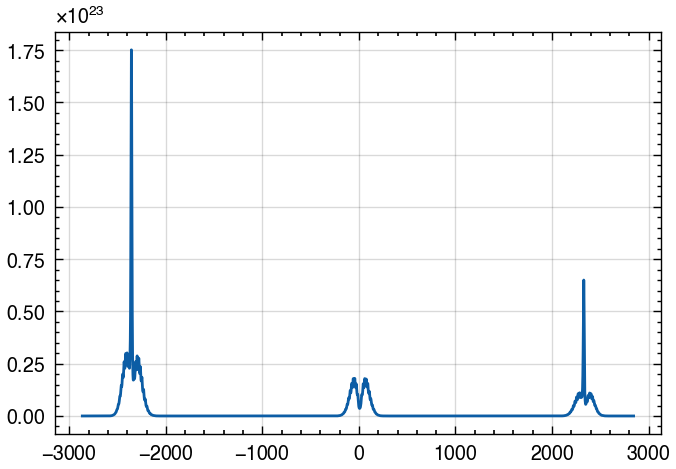

In [17]:
from ramlab.calculate_molecules import N2
import matplotlib.pyplot as plt
import wedme.apply.dev
import numpy as np
from ramlab.simulate_spectrum import simulate

M = N2

# Select the 5000 most intense transitions
transitions = M.all_transitions(laser_wavelength=532.5e-9, force_recalculate=True)
# transitions = transitions.sortby("crosssection", ascending=False)[:5000] 

# transitions = transitions[transitions.dv == 0]

# c1 = N2._calc_crosssection(transitions, 532.5e-9, "= + T")
# c2 = N2._calc_crosssection2(transitions, 532.5e-9, "= + T")

I_stick = M.get_intensity(transitions, T=300)
dnu_stick = transitions.vacuum_wavenumber

# Simulate the spectrum with Gaussian and Lorentzian broadening
dnu_sim = np.linspace(dnu_stick.min(), dnu_stick.max(), 10000)
I_sim = simulate(dnu_sim, dnu_stick, I_stick, 3, 3)

plt.figure()
plt.vlines(dnu_stick, 0, I_stick, color="r")
# plt.ylim(0, 1e21)

plt.figure()
plt.plot(dnu_sim, I_sim)
# plt.xlim(-500, 500)
# plt.ylim(0, 1e21)
plt.show()

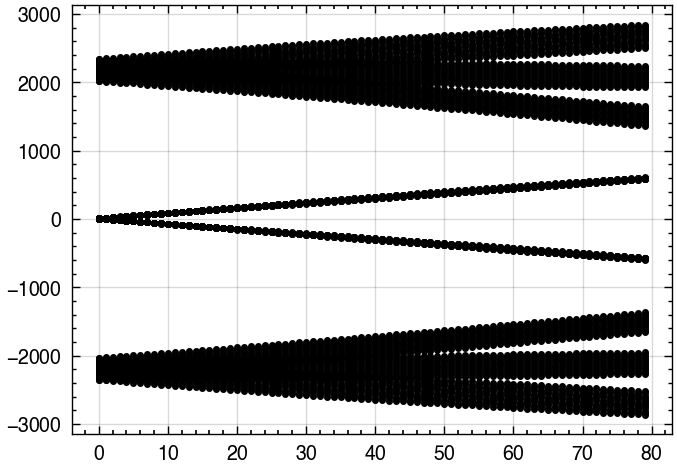

In [2]:
plt.figure()
plt.plot(transitions.initial_J, transitions.dE, 'k.')

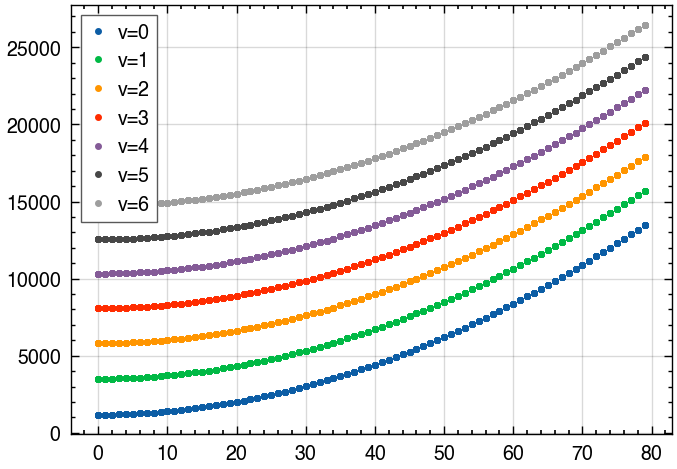

In [3]:
plt.figure()

for v in [0, 1, 2, 3, 4, 5, 6]:
    idx = transitions.initial_v == v
    plt.plot(transitions.state_initial.J[idx], transitions.state_initial.E[idx], '.', label=f"v={v}")

plt.legend()
plt.show()

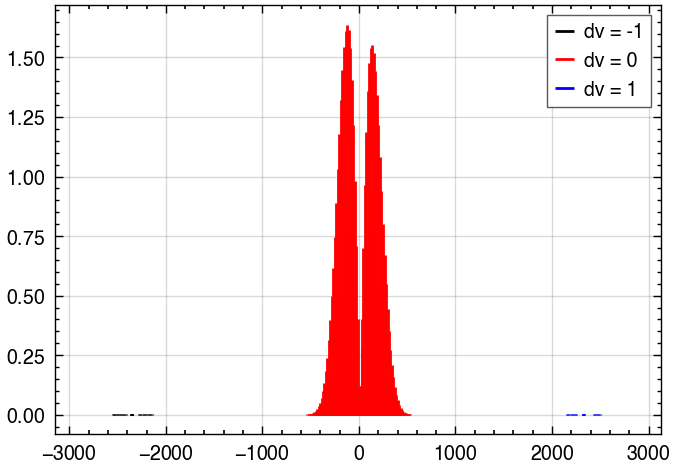

In [4]:
plt.figure()

# for i, dJ in enumerate([-2, 0, 2]):
for i, dv in enumerate([-1, 0, 1]):
    transitions_i = transitions[transitions.final_v - transitions.initial_v == dv]

    I_stick_i = M.get_intensity(transitions_i, T=1500)
    dnu_stick_i = transitions_i.vacuum_wavenumber

    plt.vlines(dnu_stick_i, 0, I_stick_i / np.nanmax(I_stick), color=["k", "r", "b"][i], label=f"dv = {dv}")
    # plt.vlines(dnu_stick_i, 0, I_stick_i / np.nanmax(I_stick), color=["k", "r", "b"][i], label=f"dJ = {dJ}")
plt.legend()
plt.show()

/var/folders/g7/92vnr90n61bf1fjkg_hw_g180000gn/T/ipykernel_87634/1122496887.py:7: RuntimeWarning: invalid value encountered in divide
  plt.plot(dnu_sim, I_sim / np.nanmax(I_sim), color="r", label="Simulated spectrum")


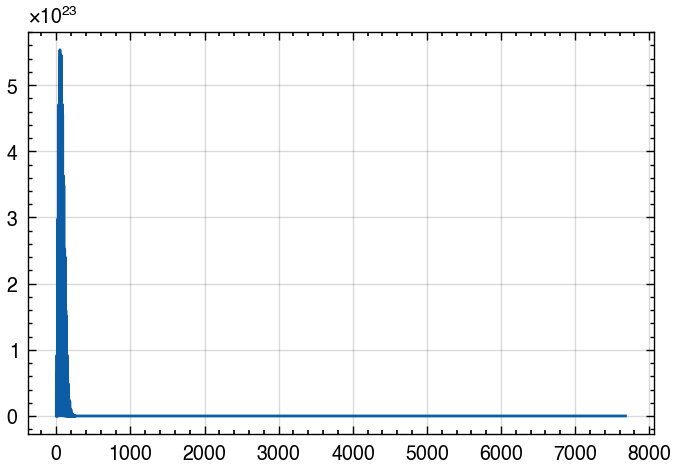

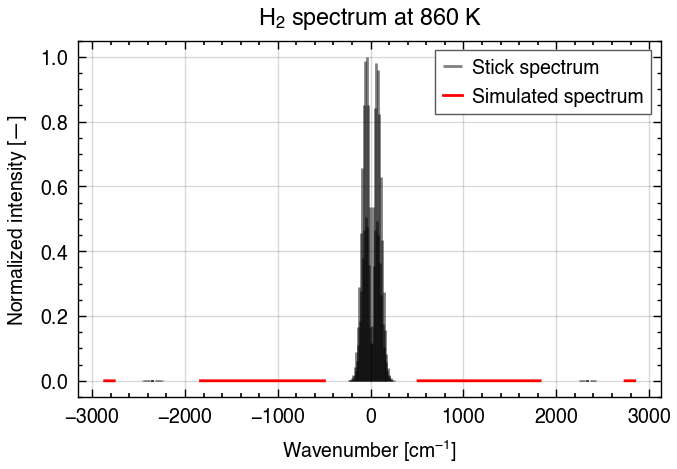

In [5]:
plt.figure()
plt.plot(I_stick)

# Plot the results
plt.figure()
plt.vlines(dnu_stick, 0, I_stick / np.nanmax(I_stick), color="k", alpha=0.5, label="Stick spectrum")
plt.plot(dnu_sim, I_sim / np.nanmax(I_sim), color="r", label="Simulated spectrum")
plt.legend()
plt.xlabel(r"Wavenumber [$\mathrm{cm^{-1}}$]")
plt.ylabel(r"Normalized intensity [$\mathrm{\emdash}$]")
plt.title(r"$\mathregular{H_2}$ spectrum at 860 K")
plt.show()